<a href="https://colab.research.google.com/github/YsmaelSG/QuantMentorshipFinalProject/blob/main/GTSFFInalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Constants/Intializaiton

In [52]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

# all the libraries for this project -> dismiss treasury yield curve data for now
pd.set_option("display.max_row",None)

In [45]:
# pulling time-series for XLE,XLK and Block(40% layoff)
startdate = datetime(2022,1,1)
block = yf.download("XYZ",start = startdate)
energy = yf.download("XLE",start = startdate)
technology = yf.download("XLK",start = startdate)

/tmp/ipykernel_2964/373202238.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  block = yf.download("XYZ",start = startdate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2964/373202238.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  energy = yf.download("XLE",start = startdate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2964/373202238.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  technology = yf.download("XLK",start = startdate)
[*********************100%***********************]  1 of 1 completed


# Data Cleaning and Processing

In [46]:
# handle missing values, outliers, inconsistent formats, structural issues
window = 30
num_std = 2

block["Return"] = block["Close"].pct_change()
block["SMA"] = block["Close"].rolling(window).mean()
block["STD"] = block["Close"].rolling(window).std()
block['ReturnSTD'] = block.Return.rolling(window).std()
block['DailyReturnSTD'] = block.Return.abs()
block["Upper"] = block["SMA"] + (num_std * block["STD"])
block["Lower"] = block["SMA"] - (num_std * block["STD"])


energy["Return"] = energy["Close"].pct_change()
energy["SMA"] = energy["Close"].rolling(window).mean()
energy["STD"] = energy["Close"].rolling(window).std()
energy['ReturnSTD'] = energy.Return.rolling(window).std()
energy['DailyReturnSTD'] = energy.Return.abs()
energy["Upper"] = energy["SMA"] + (num_std * energy["STD"])
energy["Lower"] = energy["SMA"] - (num_std * energy["STD"])

technology["Return"] = technology["Close"].pct_change()
technology["SMA"] = technology["Close"].rolling(window).mean()
technology["STD"] = technology["Close"].rolling(window).std()
technology['ReturnSTD'] = technology.Return.rolling(window).std()
technology['DailyReturnSTD'] = technology.Return.abs()
energy["Upper"] = energy["SMA"] + (num_std * energy["STD"])
energy["Lower"] = energy["SMA"] - (num_std * energy["STD"])

# not dropping outliers due to how many appear
block = block.dropna()
technology = technology.dropna()
energy = energy.dropna()

# Gives us information on entries and non-null count -> none are null and no duplicates
block.info()
energy.info()
technology.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1049 entries, 2022-02-15 to 2026-04-22
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, XYZ)        1049 non-null   float64
 1   (High, XYZ)         1049 non-null   float64
 2   (Low, XYZ)          1049 non-null   float64
 3   (Open, XYZ)         1049 non-null   float64
 4   (Volume, XYZ)       1049 non-null   int64  
 5   (Return, )          1049 non-null   float64
 6   (SMA, )             1049 non-null   float64
 7   (STD, )             1049 non-null   float64
 8   (ReturnSTD, )       1049 non-null   float64
 9   (DailyReturnSTD, )  1049 non-null   float64
 10  (Upper, )           1049 non-null   float64
 11  (Lower, )           1049 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 106.5 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1049 entries, 2022-02-15 to 2026-04-22
Data columns (total 12 columns):
 #   Column

# Exploratory Data Analysis (EDA)







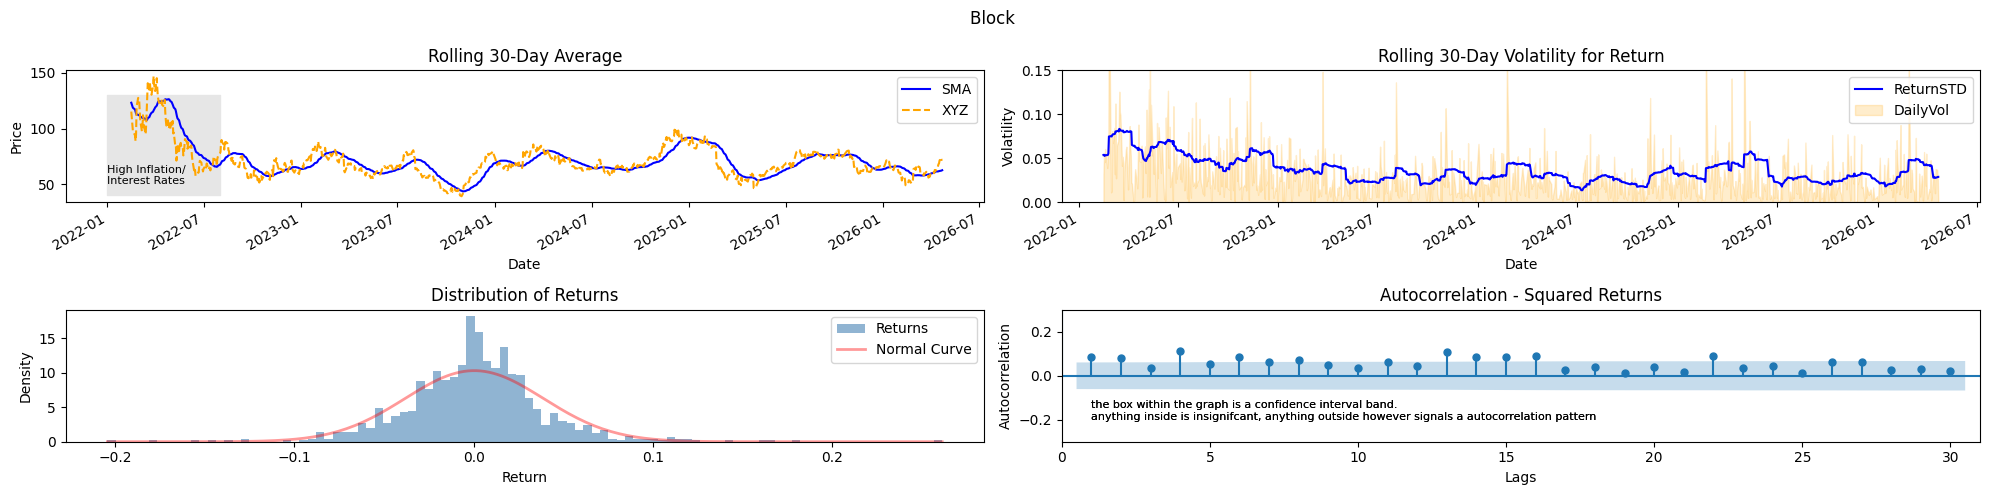

'\nFor this, look into time series models that are for stationary results,\n where we can almost do abtrtrage or mean-reversion since the price seems constant, market making\n'

In [58]:
# 1: Block


# adds time as our x axis automatically due to it being a Datetime Index
blockfig,axes = plt.subplots(2,2,figsize=(20,5))
blockfig.suptitle("Block ")
#Graph 1
block.SMA.plot(ax=axes[0][0],color="blue",title="Rolling 30-Day Average", xlabel="Date", ylabel="Price", label='SMA')
block.Close.plot(ax=axes[0][0], color='orange', linestyle='--', label='Close')
axes[0][0].legend(loc='upper right')
axes[0][0].fill_betweenx([40,130],["2022-01"],["2022-08"],color="0.9")
axes[0][0].text("2022-01",50, 'High Inflation/\nInterest Rates', fontsize=8, color='black')

# make into bolinger band(maybe)
#Graph 2
block.ReturnSTD.plot(ax=axes[0][1],color="blue",title="Rolling 30-Day Volatility for Return",xlabel="Date",ylabel="Volatility")
#block.DailyReturnSTD.plot(ax=axes[0][1], color='orange', alpha=0.3,linestyle="--", label='DailyVol')
axes[0][1].fill_between(block.index, block.DailyReturnSTD, alpha=0.2, color='orange', label='DailyVol')

axes[0][1].legend(loc='upper right')
axes[0][1].set_ylim(0, 0.15)


# get rid of this , use other graph like
#Graph 3
block.Return.plot(ax=axes[1][0], kind='hist', bins=100, density=True,color='steelblue', alpha=0.6, title='Distribution of Returns',
                  xlabel='Return', ylabel='Density', label='Returns')
mu, std = stats.norm.fit(block.Return.dropna())
# creates a smooth line to cast over the returns of block
x = np.linspace(block.Return.min(), block.Return.max(), 200)
axes[1][0].plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2,alpha=0.4, label='Normal Curve')
axes[1][1].text(1,-0.2, 'the box within the graph is a confidence interval band. \nanything inside is insignifcant, anything outside however signals a autocorrelation pattern', fontsize=8, color='black')
axes[1][0].legend()


# the box within the graph is a confidence interval band, anything inside is insignifcant, anything outside however is signals autocorrelation
#Graph 4
plot_acf(block.Return**2,lags=30,ax=axes[1][1])
axes[1][1].set_title("Autocorrelation - Squared Returns")
axes[1][1].set_xlabel("Lags")
axes[1][1].set_ylabel("Autocorrelation")
axes[1][1].set_ylim(-0.3, 0.3)
axes[1][1].set_xlim(0,31)
axes[1][1].text(1,-0.2, 'the box within the graph is a confidence interval band. \nanything inside is insignifcant, anything outside however signals a autocorrelation pattern', fontsize=8, color='black')




# make layout spaced out properly and show the graphs -> plt.show not needed in jupyter notebooks
plt.tight_layout()
plt.show()


"""
For this, look into time series models that are for stationary results,
 where we can almost do abtrtrage or mean-reversion since the price seems constant, market making
"""




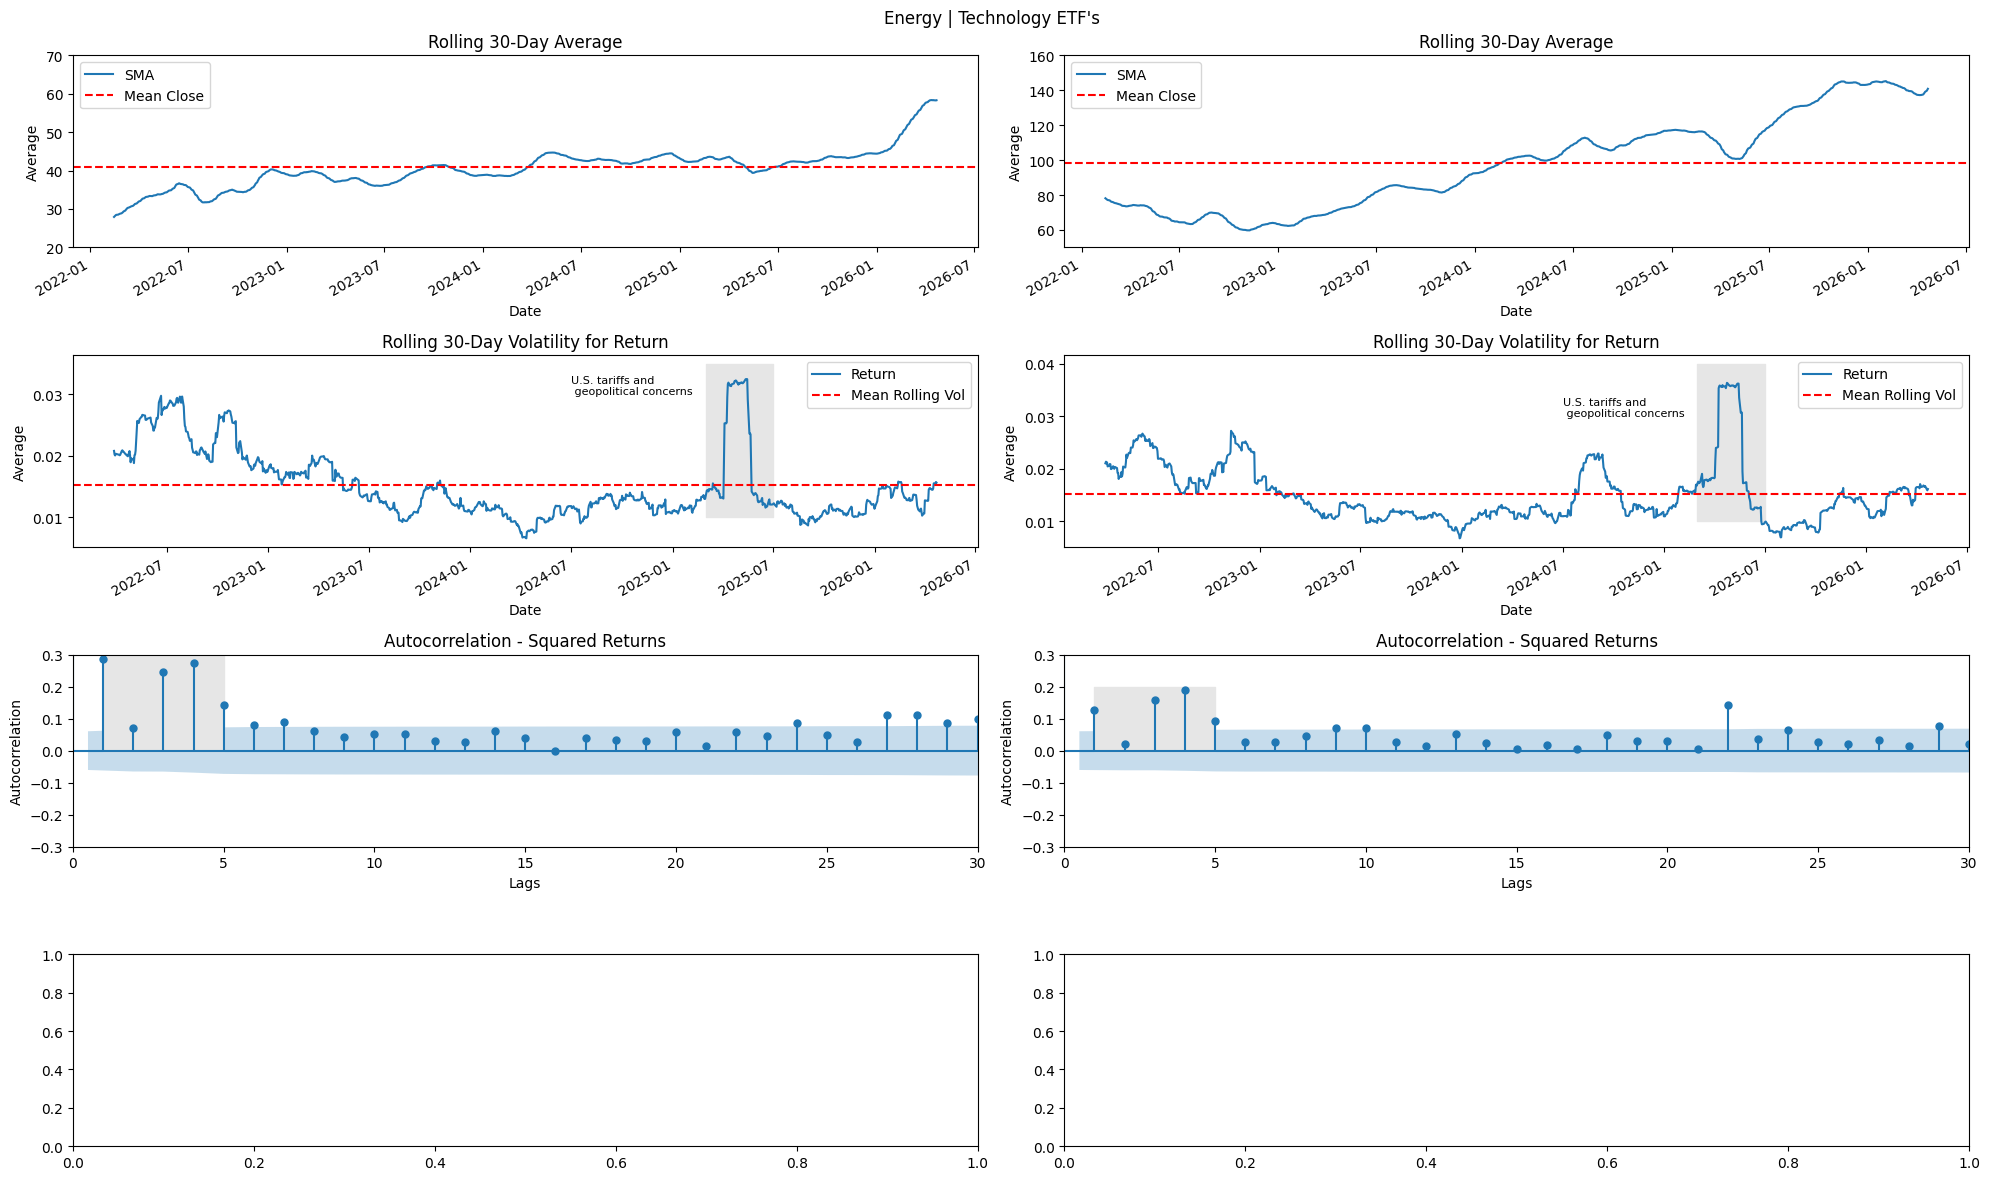

In [25]:
# 2: Energy and Technology ETF's

Etffig,etfaxes = plt.subplots(4,2,figsize=(20,12))
Etffig.suptitle("Energy | Technology ETF's ")
#Energy Graph 1 Rolling Avg
energy.SMA.plot(ax=etfaxes[0][0],title="Rolling 30-Day Average", xlabel="Date", ylabel="Average")
etfaxes[0][0].axhline(y=energy.Close.mean().mean(), color='red', linestyle='--', label='Mean Close')
etfaxes[0][0].legend(loc='upper left')
etfaxes[0][0].set_ylim(20, 70)

#Technology Graph 1 Rolling Avg
technology.SMA.plot(ax=etfaxes[0][1],title="Rolling 30-Day Average", xlabel="Date", ylabel="Average")
etfaxes[0][1].axhline(y=technology.Close.mean().mean(), color='red', linestyle='--', label='Mean Close')
etfaxes[0][1].legend(loc='upper left')
etfaxes[0][1].set_ylim(50, 160)




#Energy Graph 2 Rolling Volality
energy.Return.rolling(window=30).std().plot(ax=etfaxes[1][0],title="Rolling 30-Day Volatility for Return",xlabel="Date",ylabel="Average")
etfaxes[1][0].axhline(y=energy.Return.rolling(30).std().mean(), color='red', linestyle='--', label='Mean Rolling Vol')
etfaxes[1][0].legend(loc='upper right')
etfaxes[1][0].fill_betweenx([0.01,0.035],["2025-03"],["2025-07"],color="0.9")
etfaxes[1][0].text("2024-07",0.03, 'U.S. tariffs and \n geopolitical concerns', fontsize=8, color='black')

#Technology Graph 2 Rolling Volality
technology.Return.rolling(window=30).std().plot(ax=etfaxes[1][1],title="Rolling 30-Day Volatility for Return",xlabel="Date",ylabel="Average")
etfaxes[1][1].axhline(y=technology.Return.rolling(30).std().mean(), color='red', linestyle='--', label='Mean Rolling Vol')
etfaxes[1][1].legend(loc='upper right')
etfaxes[1][1].fill_betweenx([0.01,0.04],["2025-03"],["2025-07"],color="0.9")
etfaxes[1][1].text("2024-07",0.03, 'U.S. tariffs and \n geopolitical concerns', fontsize=8, color='black')




#imported from library statsmodels

#Graph 3 Energy Squared Return
plot_acf(energy.Return**2,lags=30,ax=etfaxes[2][0])
etfaxes[2][0].set_title("Autocorrelation - Squared Returns")
etfaxes[2][0].set_xlabel("Lags")
etfaxes[2][0].set_ylabel("Autocorrelation")
etfaxes[2][0].fill_betweenx([0.0,0.3],1,5,color="0.9")
etfaxes[2][0].set_ylim(-0.3, 0.3)
etfaxes[2][0].set_xlim(0,30)


#Graph 3 Technology Squared Return
plot_acf(technology.Return**2,lags=30,ax=etfaxes[2][1])
etfaxes[2][1].set_title("Autocorrelation - Squared Returns")
etfaxes[2][1].set_xlabel("Lags")
etfaxes[2][1].set_ylabel("Autocorrelation")
etfaxes[2][1].fill_betweenx([0.0,0.2],1,5,color="0.9")
etfaxes[2][1].set_ylim(-0.3, 0.3)
etfaxes[2][1].set_xlim(0,30)


# Graph 4 -> rolling correlation


# make layout spaced out properly and show the graphs -> plt.show not needed in jupyter notebooks
plt.tight_layout()
plt.show()



# Statistical Modeling or Forecasting

In [5]:
#for block, use garch and arch to showcase volaility clustering, and potential for mean reversion

In [ ]:
# for energy and tech, compare the two and see if correlate, and compare to see if one drops then another might as well, potential for cross trading